Penelitian ini bertujuan untuk memprediksi status kemiskinan rumah tangga menggunakan model machine learning XGBoost berbasis data survei kesehatan nasional Amerika Serikat (NHANES). Dengan memanfaatkan fitur-fitur seperti pendapatan, demografi, status kesehatan, pola makan, dan aktivitas fisik, model dilatih untuk mengklasifikasikan apakah suatu individu termasuk dalam kategori miskin atau tidak miskin — berdasarkan rasio pendapatan terhadap garis kemiskinan (INDFMPIR < 1).

##  Alur Notebook

1. Load Data       — Membaca dan menggabungkan 7 file NHANES
2. Cleaning        — Seleksi kolom dan penanganan missing value
3. Fitur Gabungan  — Feature engineering dari kolom mentah
4. Preprocessing   — Split data, imputasi, cek distribusi kelas
5. Training ML     — XGBoost + hyperparameter tuning
6. Evaluasi        — Confusion matrix, ROC, PR Curve, SHAP

# Load Data

7 file data NHANES berformat .xpt (format SAS) yang masing-masing berisi data berbeda:
* demografis (DEMO)
* BMI (BMX)
* tekanan darah (BPX)
* diabetes (DIQ)
* merokok (SMQ)
* aktivitas fisik (PAQ)
* asupan gizi (DR1TOT)

In [2]:
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/data_kemiskinan"

print(f"Folder yang digunakan: {folder_path}")

try:
    demo = pd.read_sas(os.path.join(folder_path, "DEMO_J.xpt"))
    bmx  = pd.read_sas(os.path.join(folder_path, "BMX_J.xpt"))
    bpx  = pd.read_sas(os.path.join(folder_path, "BPX_J.xpt"))
    diq  = pd.read_sas(os.path.join(folder_path, "DIQ_J.xpt"))
    smq  = pd.read_sas(os.path.join(folder_path, "SMQ_J.xpt"))
    paq  = pd.read_sas(os.path.join(folder_path, "PAQ_J.xpt"))
    dr1  = pd.read_sas(os.path.join(folder_path, "DR1TOT_J.xpt"))

    print("Semua file XPT berhasil dibaca.")

except Exception as e:
    print(f" ERROR saat membaca file: {e}")

Mounted at /content/drive
Folder yang digunakan: /content/drive/MyDrive/data_kemiskinan
Semua file XPT berhasil dibaca.


In [3]:
#gabungin data
df = demo.merge(bmx, on="SEQN", how="left") \
         .merge(bpx, on="SEQN", how="left") \
         .merge(diq, on="SEQN", how="left") \
         .merge(smq, on="SEQN", how="left") \
         .merge(paq, on="SEQN", how="left") \
         .merge(dr1, on="SEQN", how="left")

print("gabung")

# simpan csv
output_file_path = os.path.join(folder_path, "nhanes_merged.csv")
df.to_csv(output_file_path, index=False)

print("\n--- HASIL AKHIR ---")
print(f"Data berhasil digabung dan disimpan sebagai **nhanes_merged.csv**")
print(f"Lokasi penyimpanan (di Colab): {output_file_path}")
print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

gabung

--- HASIL AKHIR ---
Data berhasil digabung dan disimpan sebagai **nhanes_merged.csv**
Lokasi penyimpanan (di Colab): /content/drive/MyDrive/data_kemiskinan/nhanes_merged.csv
Jumlah baris: 9254
Jumlah kolom: 358


# Cleaning


In [4]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_kemiskinan/nhanes_merged.csv'

df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  93703.0      10.0       2.0       2.0       2.0       NaN       5.0   
1  93704.0      10.0       2.0       1.0       2.0       NaN       3.0   
2  93705.0      10.0       2.0       2.0      66.0       NaN       4.0   
3  93706.0      10.0       2.0       1.0      18.0       NaN       5.0   
4  93707.0      10.0       2.0       1.0      13.0       NaN       5.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DRD370QQ  DRD370R  DRD370RQ  DRD370S  \
0       6.0       2.0      27.0  ...       NaN      NaN       NaN      NaN   
1       3.0       1.0      33.0  ...       NaN      2.0       NaN      2.0   
2       4.0       2.0       NaN  ...       NaN      NaN       NaN      NaN   
3       6.0       2.0     222.0  ...       NaN      2.0       NaN      2.0   
4       7.0       2.0     158.0  ...

Dari ratusan kolom NHANES, hanya 19 kolom relevan yang diambil — mencakup demografi, kesehatan, gizi, aktivitas fisik, dan pendapatan.

In [5]:
import pandas as pd
from google.colab import drive
import os
import numpy as np

file_path = '/content/drive/MyDrive/data_kemiskinan/nhanes_merged.csv'


df = pd.read_csv(file_path)

# kolom yg mau
cols = [
    "RIAGENDR", "RIDAGEYR", "RIDRETH3", "DMDEDUC2", "BMXBMI",
    "BPXSY1", "BPXDI1", "DIQ010", "SMQ020", "PAQ605", "PAQ620",
    "DR1TKCAL", "DR1TPROT", "DR1TTFAT", "DR1TCARB",
    "DMDCITZN", "DMDHHSIZ", "INDHHIN2", "INDFMPIR"
]

# ambil kolom dari cols di atas
available_cols = [c for c in cols if c in df.columns]
df = df[available_cols]


# Fitur Gabungan

1. BP_STATUS (Status Tekanan Darah)

Dua kolom tekanan darah sistolik (BPXSY1) dan diastolik (BPXDI1) digabung menjadi satu kolom BP_STATUS dengan nilai 1 (Normal), 2 (Pre-hipertensi), atau 3 (Hipertensi)

In [6]:
# 1. Status Tekanan Darah (Hypertension Status)
def get_bp_status(systolic, diastolic):
    if (systolic >= 140) or (diastolic >= 90):
        return 3 # Hipertensi
    elif (systolic >= 120 and systolic < 140) or (diastolic >= 80 and diastolic < 90):
        return 2 # Pre-hipertensi
    else:
        return 1 # Normal

df['BP_STATUS'] = df.apply(lambda row: get_bp_status(row['BPXSY1'], row['BPXDI1']), axis=1)
df.drop(columns=['BPXSY1', 'BPXDI1'], inplace=True)




2. Ratio Makronutrien

Kolom asupan protein, lemak, dan karbohidrat dikonversi menjadi proporsi terhadap total makronutrien. Hasilnya: Ratio_Carb, Ratio_Prot, Ratio_Fat. Ini lebih informatif daripada nilai mentah kalori karena merefleksikan keseimbangan pola makan.

In [7]:
# 2. Keseimbangan Gizi (Rasio Makronutrien PENUH) <- MODIFIKASI DI SINI
df['Total_Makro'] = df['DR1TPROT'] + df['DR1TTFAT'] + df['DR1TCARB']
df['Ratio_Carb'] = np.where(df['Total_Makro'] > 0, df['DR1TCARB'] / df['Total_Makro'], 0)
df['Ratio_Prot'] = np.where(df['Total_Makro'] > 0, df['DR1TPROT'] / df['Total_Makro'], 0) # TAMBAHAN FITUR BARU
df['Ratio_Fat'] = np.where(df['Total_Makro'] > 0, df['DR1TTFAT'] / df['Total_Makro'], 0)  # TAMBAHAN FITUR BARU

# Drop fitur mentah yg udah kepake
df.drop(columns=['DR1TPROT', 'DR1TTFAT', 'DR1TCARB', 'DR1TKCAL', 'Total_Makro'], inplace=True)



3. PA_SCORE (Aktivitas Fisik)

Dua pertanyaan aktivitas fisik (PAQ605 = kerja fisik berat, PAQ620 = olahraga) digabung jadi satu skor PA_SCORE bernilai 0, 1, atau 2.

In [8]:
# 3. Aktivitas Fisik Total (PA Score)
df['PAQ605_Aktif'] = np.where(df['PAQ605'] == 1, 1, 0)
df['PAQ620_Aktif'] = np.where(df['PAQ620'] == 1, 1, 0)
df['PA_SCORE'] = df['PAQ605_Aktif'] + df['PAQ620_Aktif']

#drop lg
df.drop(columns=['PAQ605', 'PAQ620', 'PAQ605_Aktif', 'PAQ620_Aktif'], inplace=True)



3. Health_Risk_Count (Komorbiditas)

Kolom diabetes (DIQ010) dan merokok (SMQ020) dijadikan binary (ya/tidak), lalu dijumlahkan menjadi Health_Risk_Count — menunjukkan berapa banyak faktor risiko kesehatan yang dimiliki seseorang.

In [9]:
# 4. Kesehatan Umum (Komorbiditas)
df['DIQ010_Clean'] = np.where(df['DIQ010'] == 1, 1, 0) # diabetes?
df['SMQ020_Clean'] = np.where(df['SMQ020'] == 1, 1, 0) # pernah merokok?
# Hitung jumlah risiko
df['Health_Risk_Count'] = df['DIQ010_Clean'] + df['SMQ020_Clean']

df.drop(columns=['DIQ010', 'SMQ020', 'DIQ010_Clean', 'SMQ020_Clean'], inplace=True)




3. Income_Per_Capita & Label Target

* Income_Per_Capita dibuat dari pendapatan rumah tangga dibagi jumlah anggota keluarga
* INDHHIN2 asli di-drop karena sudah terwakili
*  Kolom INDFMPIR (rasio pendapatan terhadap garis kemiskinan) dipakai untuk membuat label target: PovertyStatus = 1 jika nilainya < 1 (miskin), lalu kolom ini di-drop


In [10]:
#pendapatan perkapita
# INDHHIN2 = kategori pendapatan rumah tangga
# DMDHHSIZ = jumlah anggota keluarga
df['Income_Per_Capita'] = np.where(df['DMDHHSIZ'] > 0, df['INDHHIN2'] / df['DMDHHSIZ'], 0)


df = df.drop(columns=['INDHHIN2'])

# kalau baris di kolom rasio pendapatan gd, apus aja. ambil yg ada aja
df = df.dropna(subset=["INDFMPIR"])

# abis di drop baris yg gd, disini buat label miskin dan ga
# INDFMPIR < 1 artinya miskin
df["PovertyStatus"] = df["INDFMPIR"].apply(lambda x: 1 if x < 1 else 0)

# di drop kolom rasionya
df = df.drop(columns=["INDFMPIR"])

# Hapus baris nan
df = df.dropna()

print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

Jumlah baris: 4477
Jumlah kolom: 15


In [11]:
# Hapus kolom yang kosongnya lebih dari 50%
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
df.drop(columns=cols_to_drop, inplace=True)
print(f"🗑 Dihapus {len(cols_to_drop)} kolom kosong >50%")

output_path = f"{folder_path}/nhanes_Bersih_banget_rek.csv"
df.to_csv(output_path, index=False)

🗑 Dihapus 0 kolom kosong >50%


# prepocesing


In [12]:
from google.colab import drive


#disini di nhanes_cleaned_final.csv udah di uload ke gdrive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/dataset/nhanes_Bersih_banget_rek.csv'
data_clean = pd.read_csv(file_path)

#baca info data_clean
print(data_clean.info())
print(len(data_clean.columns))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4477 entries, 0 to 4476
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RIAGENDR           4477 non-null   float64
 1   RIDAGEYR           4477 non-null   float64
 2   RIDRETH3           4477 non-null   float64
 3   DMDEDUC2           4477 non-null   float64
 4   BMXBMI             4477 non-null   float64
 5   DMDCITZN           4477 non-null   float64
 6   DMDHHSIZ           4477 non-null   float64
 7   INDHHIN2           4477 non-null   float64
 8   BP_STATUS          4477 non-null   int64  
 9   Ratio_Carb         4477 non-null   float64
 10  Ratio_Prot         4477 non-null   float64
 11  Ratio_Fat          4477 non-null   float64
 12  PA_SCORE           4477 non-null   int64  
 13  Health_Risk_Count  4477 non-null   int6

Visualisasi Distribusi Kelas
Ditampilkan bar chart untuk melihat perbandingan jumlah data kelas Miskin vs Tidak Miskin — penting untuk mendeteksi apakah data imbalanced.

PovertyStatus
0    3664
1     813
Name: count, dtype: int64


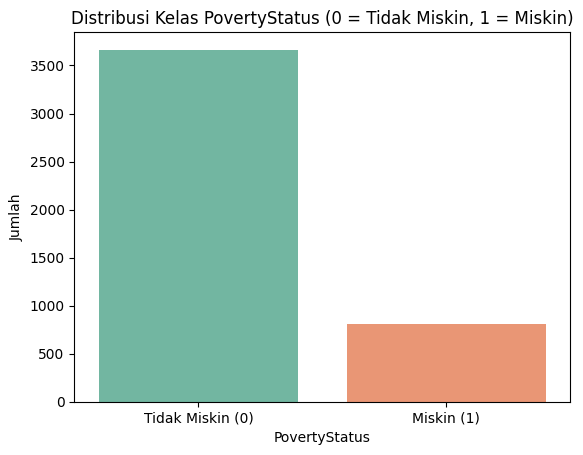

In [13]:
#karena tadi udah pisah antara miskin dan ga, mau liat perbandingan
import seaborn as sns
import matplotlib.pyplot as plt

count = df["PovertyStatus"].value_counts()
print(count)


sns.barplot(x=count.index, y=count.values, hue=count.index, palette="Set2", legend=False)
plt.title("Distribusi Kelas PovertyStatus (0 = Tidak Miskin, 1 = Miskin)")
plt.xlabel("PovertyStatus")
plt.ylabel("Jumlah")
plt.xticks([0,1], ["Tidak Miskin (0)", "Miskin (1)"])
plt.show()

Data keseluruhan sangat tidak seimbang: sekitar 3.600 orang Tidak Miskin vs hanya ~800 orang Miskin. Rasionya kira-kira 4:1. Inilah kenapa kita pakai scale_pos_weight — supaya model tidak "malas" belajar kelas minoritas (Miskin).

Split Data & Imputasi

* Data dipisah menjadi fitur (X) dan target (y)
* Di-split 80% train / 20% test dengan stratify agar proporsi kelas tetap seimbang
* SimpleImputer dipakai untuk mengisi nilai kosong yang tersisa menggunakan median — difit hanya di data train supaya tidak terjadi data leakage ke test set
* Dihitung ratio kelas mayoritas vs minoritas untuk dipakai di parameter scale_pos_weight model

scale_pos_weight yang akan dipakai: 4.51

Jumlah data latih: 3581


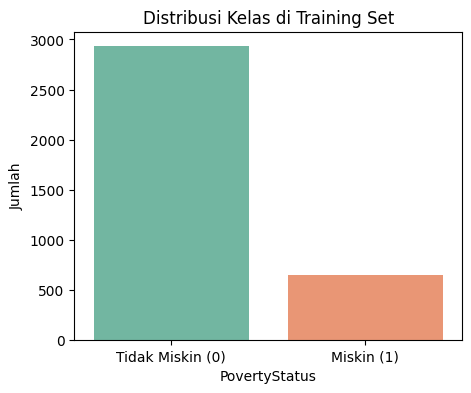

In [14]:
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
from sklearn.impute import SimpleImputer



# Pisahkan fitur dan target
X_initial = df.drop(columns=["PovertyStatus"])
y_initial = df["PovertyStatus"]


# Split DULU dari data asli (tidak ada resampling)
X_train, X_test, y_train, y_test = train_test_split(
    X_initial, y_initial, test_size=0.2, random_state=42, stratify=y_initial
)

imputer = SimpleImputer(strategy='median')  # ganti 'most_frequent' untuk kategorikal
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

# Hitung rasio untuk scale_pos_weight
ratio = Counter(y_train)[0] / Counter(y_train)[1]
print(f"scale_pos_weight yang akan dipakai: {ratio:.2f}")
print(f"\nJumlah data latih: {len(X_train)}")



count_train = pd.Series(y_train).value_counts()
plt.figure(figsize=(5,4))
sns.barplot(x=count_train.index, y=count_train.values, hue=count_train.index, palette="Set2", legend=False)
plt.title("Distribusi Kelas di Training Set")
plt.xlabel("PovertyStatus")
plt.ylabel("Jumlah")
plt.xticks([0,1], ["Tidak Miskin (0)", "Miskin (1)"])
plt.show()

Setelah di-split 80/20, proporsi tetap terjaga (~3.000 vs ~650). Ini bukti stratify=y_initial bekerja dengan benar — rasio kelas di train set sama dengan data aslinya.

# training ML



Training XGBoost + Hyperparameter Tuning

* Model XGBClassifier dibuat dengan scale_pos_weight=ratio untuk menangani ketidakseimbangan kelas tanpa harus membuang data
* RandomizedSearchCV dengan 20 iterasi dan 5-fold cross-validation dijalankan untuk mencari kombinasi hyperparameter terbaik berdasarkan F1-Score
* Model terbaik disimpan ke best_xgb_final_new
* Prediksi probabilitas dihitung untuk kemudian dicari threshold optimal via Precision-Recall curve

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=ratio
)

# Parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.3],
    'min_child_weight': [1, 5]
}


search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#tunning
search.fit(X_train, y_train)

print("\n" + "="*60)
print("Parameter terpilih untuk F1:")
print(search.best_params_,"\n")

# Gunakan model terbaik
best_xgb_final_new = search.best_estimator_

# Prediksi probabilitas kelas 1
y_proba_new = best_xgb_final_new.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_proba_new)
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores[np.isnan(f1_scores)] = 0

best_idx = np.argmax(f1_scores)
best_threshold_new = thresholds[best_idx]
best_f1_new = f1_scores[best_idx]
best_recall_new = recall[best_idx]
best_precision_new = precision[best_idx]

# Prediksi dengan threshold terbaik
y_pred_opt_new = (y_proba_new >= best_threshold_new).astype(int)

#  Tampilkan Hasil Akhir
print("\n" + "="*60)
print(f"threshold: {best_threshold_new:.4f}")
print("="*60)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Parameter terpilih untuk F1:
{'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8} 


threshold: 0.5745


# visual


In [16]:
!pip install shap

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, f1_score, recall_score, precision_score
)


# Prediksi probabilitas dan kelas
y_proba = best_xgb_final_new.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba >= best_threshold_new).astype(int)


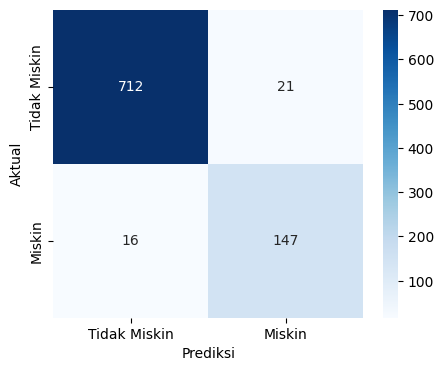

In [18]:

# matix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_opt),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Miskin", "Miskin"],
            yticklabels=["Tidak Miskin", "Miskin"])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


Akurasi keseluruhan bagus, dari seluruh data, hanya 16 orang miskin yang tidak miskin dan 21 orang tidak miskin di klasifikasikan miskin


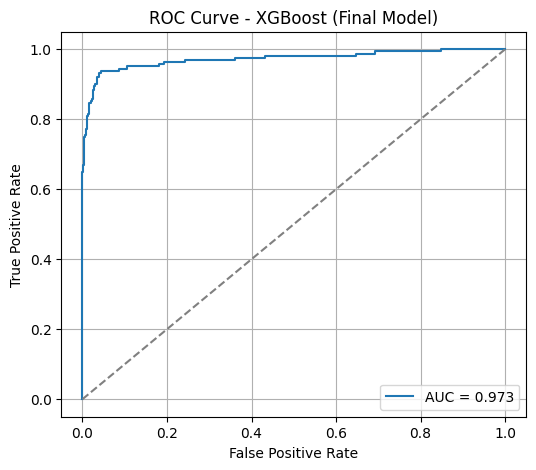

In [19]:
#roc
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('ROC Curve - XGBoost (Final Model)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


AUC 0.973 artinya model 97.3% mampu membedakan orang miskin vs tidak miskin. Kurva naik sangat tajam ke pojok kiri atas — ini tanda model sangat kuat. Nilai AUC di atas 0.95 sudah tergolong excellent.

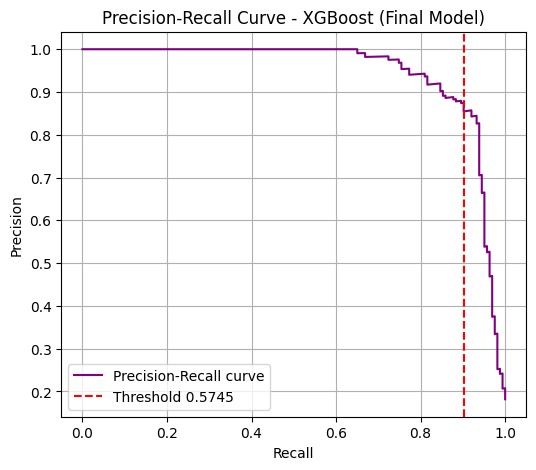

In [20]:
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve)

plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve, color='purple', label='Precision-Recall curve')

# Use best_recall_new and best_threshold_new
plt.axvline(best_recall_new, color='red', linestyle='--', label=f'Threshold {best_threshold_new:.4f}')
plt.title('Precision-Recall Curve - XGBoost (Final Model)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


Kurva menunjukkan precision tetap tinggi (~90%+) sampai recall mencapai ~0.9. Garis merah putus-putus di threshold 0.5745 adalah titik optimal F1 yang dipilih otomatis — titik dimana keseimbangan precision dan recall paling baik.

In [22]:
import shap
# top faktor penyebab miskin
explainer = shap.TreeExplainer(best_xgb_final_new)
shap_values = explainer.shap_values(X_test)


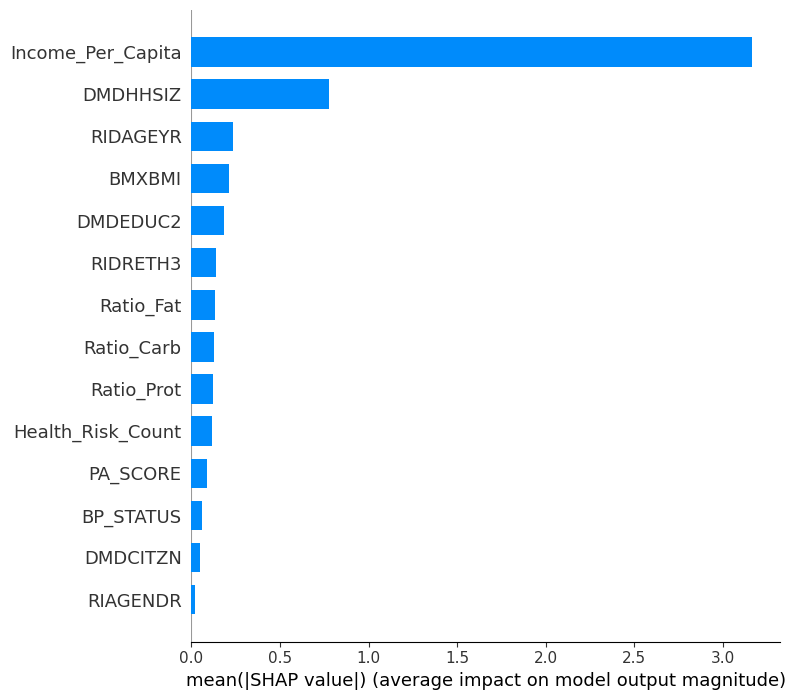

In [23]:
# SHAP summary plot — arah & besar pengaruh tiap fitur
shap.summary_plot(shap_values, X_test, plot_type="bar")   # versi bar


Urutan fitur berdasarkan seberapa besar pengaruhnya ke prediksi model
* Income_Per_Capita = Pendapatan per anggota keluarga
* DMDHHSIZ = Jumlah anggota keluarga
* RIDAGEYR = Usia
* BMXBMI = Indeks massa tubuh
* DMDEDUC2 = Tingkat pendidikan
* SisanyaPengaruh lebih kecil

DMDHHSIZ (ukuran keluarga) masuk peringkat 2, karena Income_Per_Capita dihitung dari INDHHIN2 / DMDHHSIZ, jadi model tau kalau keduanya saling berkaitan.

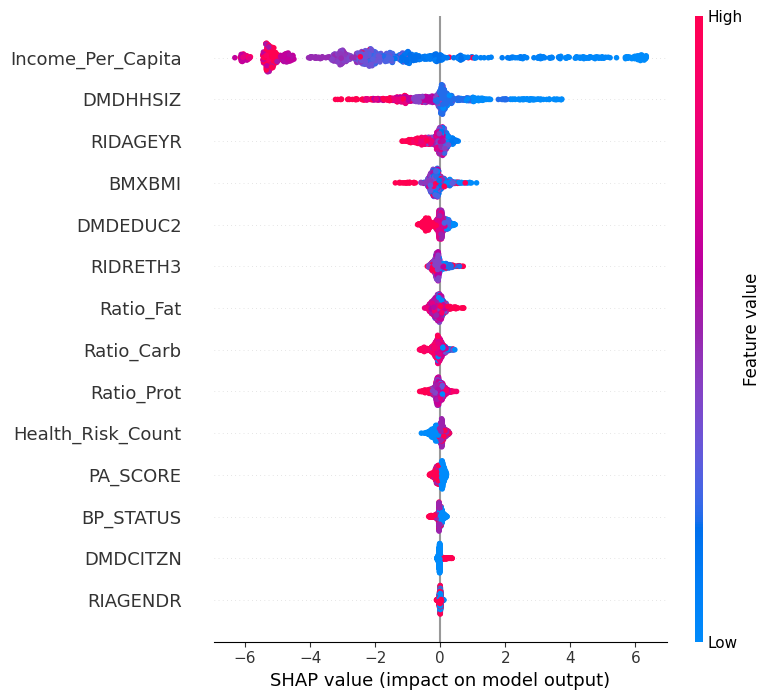

In [24]:
shap.summary_plot(shap_values, X_test)
plt.show()

Model ini memberitahu bahwa faktor ekonomi (pendapatan & ukuran keluarga) sebagai prediktor utama kemiskinan, dengan faktor demografis (usia, pendidikan, etnis) sebagai pendukung.